In [54]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

In [55]:
# Dataset tùy chỉnh:
# - Đọc file CSV (tên ảnh + label)
# - Load ảnh từ thư mục
# - Trả về (image, label)
class CIFAR10Custom(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.data = pd.read_csv(csv_file)
        self.transform = transform

        # encode label
        self.label_map = {
            label: idx for idx, label in enumerate(self.data.iloc[:, 1].unique())
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = str(self.data.iloc[idx, 0])
        if not img_name.endswith(".png"):
            img_name += ".png"

        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # encode label
        label_str = self.data.iloc[idx, 1]
        label = self.label_map[label_str]

        return image, torch.tensor(label, dtype=torch.long)

In [56]:
# Tiền xử lý ảnh + tạo DataLoader
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = CIFAR10Custom(
    root_dir="data/train/train",
    csv_file="data/trainLabels.csv",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [57]:
# Mô hình CNN cơ bản (LeNet-5)
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.Tanh(),
            nn.AvgPool2d(2),

            nn.Conv2d(6, 16, 5),
            nn.Tanh(),
            nn.AvgPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(16*5*5, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [58]:
# VGG-16 đơn giản hóa cho CIFAR-10
class VGG16(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 64),
            block(64, 128),
            block(128, 256),
            block(256, 512)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512*2*2, 4096),
            nn.ReLU(),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [59]:
# Inception block cơ bản
class Inception(nn.Module):
    def __init__(self, in_c, out1, out3, out5):
        super().__init__()
        self.b1 = nn.Conv2d(in_c, out1, 1)

        self.b3 = nn.Sequential(
            nn.Conv2d(in_c, out3, 1),
            nn.Conv2d(out3, out3, 3, padding=1)
        )

        self.b5 = nn.Sequential(
            nn.Conv2d(in_c, out5, 1),
            nn.Conv2d(out5, out5, 5, padding=2)
        )

    def forward(self, x):
        return torch.cat([self.b1(x), self.b3(x), self.b5(x)], 1)


# GoogLeNet đơn giản
class GoogLeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 64, 3, padding=1)
        self.inception = Inception(64, 32, 32, 32)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(96*16*16, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.inception(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [60]:
# Residual block (skip connection)
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c)
        )
        self.shortcut = nn.Conv2d(in_c, out_c, 1)

    def forward(self, x):
        return nn.ReLU()(self.conv(x) + self.shortcut(x))


# ResNet đơn giản
class ResNet50(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = ResidualBlock(3, 64)
        self.pool = nn.MaxPool2d(2)
        self.layer2 = ResidualBlock(64, 128)
        self.fc = nn.Linear(128*16*16, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.pool(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [74]:
def train_model(model, train_loader, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        loss_history.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model, loss_history

In [62]:
# Hàm đánh giá accuracy
def evaluate_model(model, data_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

In [75]:
results = {}

# LeNet
print("Training LeNet...")
lenet , loss_lenet = train_model(LeNet5(), train_loader)
results["LeNet-5"] = evaluate_model(lenet, train_loader)

# VGG
print("Training VGG...")
vgg , loss_vgg= train_model(VGG16(), train_loader)
results["VGG-16"] = evaluate_model(vgg, train_loader)

# GoogLeNet
print("Training GoogLeNet...")
googlenet , loss_google = train_model(GoogLeNet(), train_loader)
results["GoogLeNet"] = evaluate_model(googlenet, train_loader)

# ResNet
print("Training ResNet...")
resnet , loss_resnet = train_model(ResNet50(), train_loader)
results["ResNet-50"] = evaluate_model(resnet, train_loader)

Training LeNet...
Epoch 1, Loss: 1368.2350
Epoch 2, Loss: 1166.0449
Epoch 3, Loss: 1072.4357
Epoch 4, Loss: 1008.3125
Epoch 5, Loss: 958.7434
Training VGG...
Epoch 1, Loss: 1292.2059
Epoch 2, Loss: 879.7431
Epoch 3, Loss: 683.8835
Epoch 4, Loss: 558.0910
Epoch 5, Loss: 465.2460
Training GoogLeNet...
Epoch 1, Loss: 1032.9809
Epoch 2, Loss: 809.5640
Epoch 3, Loss: 729.3464
Epoch 4, Loss: 670.8440
Epoch 5, Loss: 618.1887
Training ResNet...
Epoch 1, Loss: 1032.5345
Epoch 2, Loss: 594.9408
Epoch 3, Loss: 411.8421
Epoch 4, Loss: 274.5598
Epoch 5, Loss: 169.1893


In [76]:
# In bảng kết quả
print("\n=== KẾT QUẢ SO SÁNH ===")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


=== KẾT QUẢ SO SÁNH ===
LeNet-5: 0.5841
VGG-16: 0.8119
GoogLeNet: 0.7942
ResNet-50: 0.9609


In [77]:
import pandas as pd

df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(df)

       Model  Accuracy
0    LeNet-5   0.58406
1     VGG-16   0.81194
2  GoogLeNet   0.79424
3  ResNet-50   0.96086


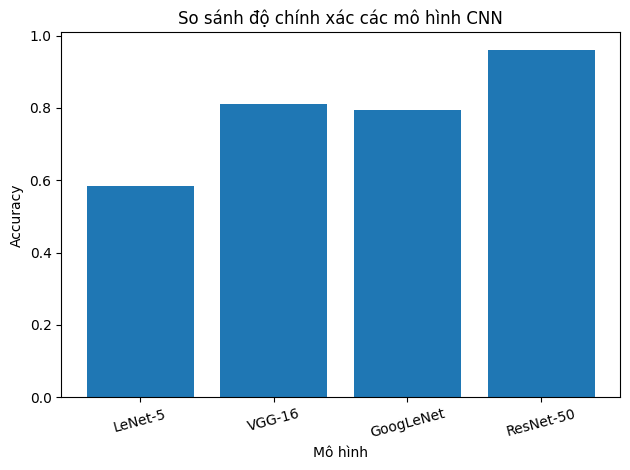

In [78]:
import matplotlib.pyplot as plt

# dữ liệu từ results
models = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(models, accuracies)

plt.title("So sánh độ chính xác các mô hình CNN")
plt.xlabel("Mô hình")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

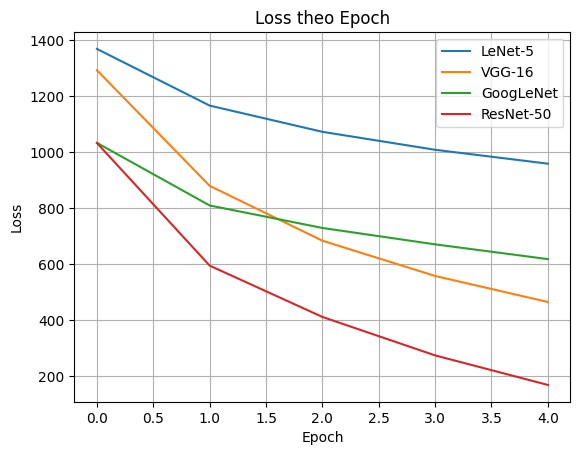

In [80]:
plt.figure()

plt.plot(loss_lenet, label="LeNet-5")
plt.plot(loss_vgg, label="VGG-16")
plt.plot(loss_google, label="GoogLeNet")
plt.plot(loss_resnet, label="ResNet-50")

plt.title("Loss theo Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()
plt.show()

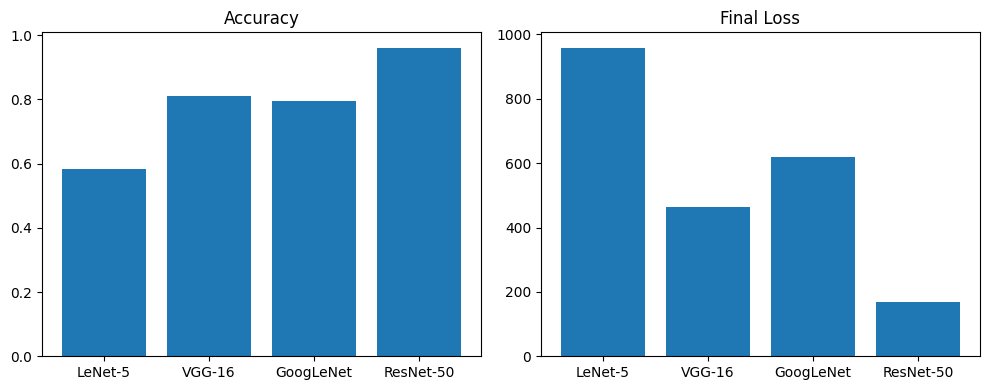

In [81]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))

# Accuracy
axs[0].bar(models, accuracies)
axs[0].set_title("Accuracy")

# Loss (epoch cuối)
final_losses = [
    loss_lenet[-1],
    loss_vgg[-1],
    loss_google[-1],
    loss_resnet[-1]
]

axs[1].bar(models, final_losses)
axs[1].set_title("Final Loss")

plt.tight_layout()
plt.show()